## HPA Cell Line Descriptions — `11_hpa_rna_celline_description.tsv`

1,206 rows — one per cell line in the HPA RNA expression file. Provides cancer type, tissue, and `Cellosaurus ID`, which is the bridge that connects HPA cell line names into the DepMap/Cellosaurus ecosystem. This file is how you go from an HPA cell line name to a `CVCL_` accession and then to a DepMap `ModelID`.

In [1]:
import __init__ as ini
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100


In [2]:
df = pd.read_csv(ini.df11, sep="\t")

In [3]:
df

,Cell line,Disease,Disease subtype,Cellosaurus ID,Patient,Primary/Metastasis,Sample collection site
0,143B,Bone cancer,Osteosarcoma,CVCL_2270,13,Primary,bone
1,22Rv1,Prostate cancer,Adenocarcinoma,CVCL_1045,Male,primary,prostate
2,23132/87,Gastric cancer,Adenocarcinoma,CVCL_1046,"Male, 72",primary,stomach
3,253J,Bladder cancer,Carcinoma,CVCL_7935,"Male, 53",metastasis,lymph node
4,253J-BV,Bladder cancer,Carcinoma,CVCL_7937,"Male, 53",metastasis,lymph node
...,...,...,...,...,...,...,...
1201,YH-13,Brain cancer,Glioblastoma,CVCL_1795,"Male, 40",primary,central nervous system
1202,YKG-1,Brain cancer,Glioblastoma,CVCL_1796,"Female, 53",primary,central nervous system
1203,YMB-1,Breast cancer,Breast Ductal Carcinoma,CVCL_2814,63,Metastasis,ascites
1204,ZR-75-1,Breast cancer,Breast Ductal Carcinoma,CVCL_0588,"Female, 63",metastasis,ascites


### Disease & tissue distributions
Which cancer types are represented in the HPA data, and where were the tumours collected?

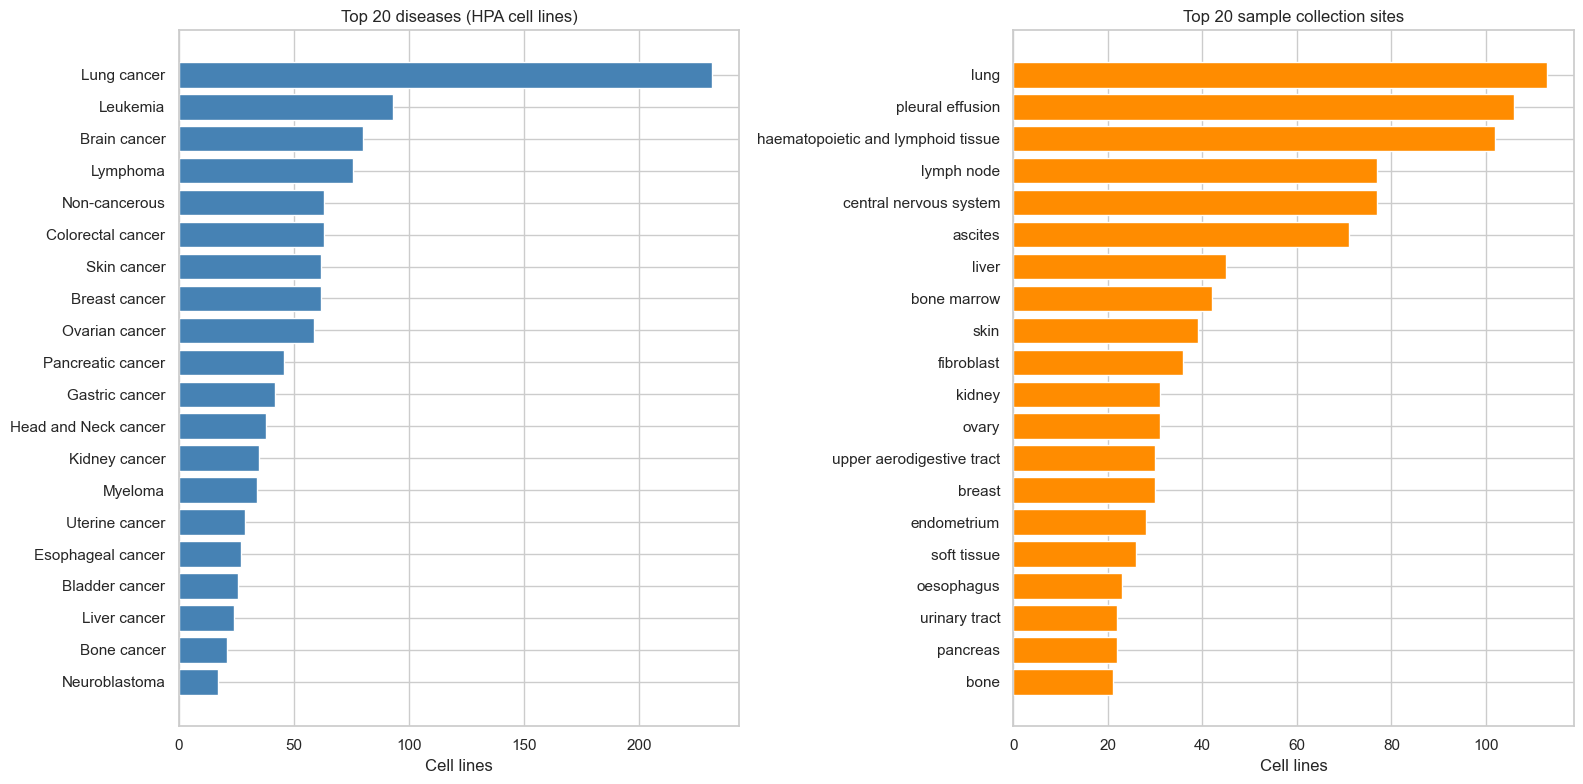

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_disease = df["Disease"].value_counts().head(20)
axes[0].barh(top_disease.index[::-1], top_disease.values[::-1], color="steelblue")
axes[0].set_title("Top 20 diseases (HPA cell lines)")
axes[0].set_xlabel("Cell lines")

top_site = df["Sample collection site"].value_counts().head(20)
axes[1].barh(top_site.index[::-1], top_site.values[::-1], color="darkorange")
axes[1].set_title("Top 20 sample collection sites")
axes[1].set_xlabel("Cell lines")

plt.tight_layout(); plt.show()


### Primary vs metastasis & disease subtypes
Metastatic models may behave differently from primary tumour models in drug experiments.

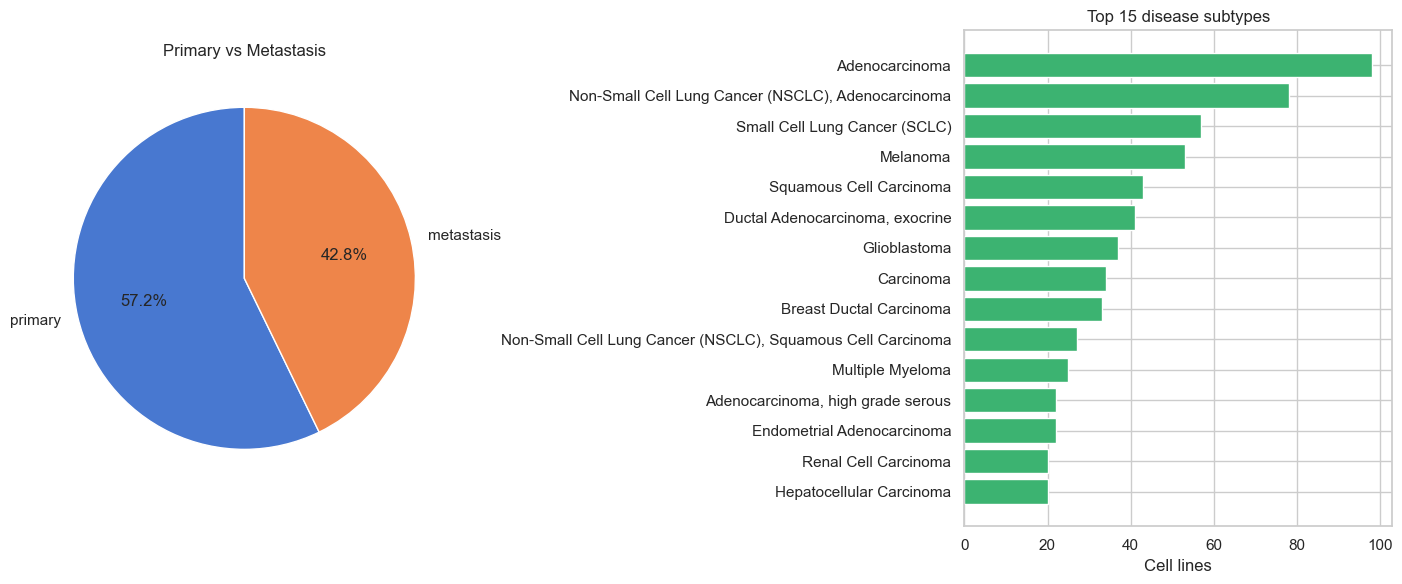

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pm = df["Primary/Metastasis"].str.lower().str.strip().value_counts()
axes[0].pie(pm.values, labels=pm.index, autopct="%1.1f%%", startangle=90)
axes[0].set_title("Primary vs Metastasis")

top_sub = df["Disease subtype"].value_counts().head(15)
axes[1].barh(top_sub.index[::-1], top_sub.values[::-1], color="mediumseagreen")
axes[1].set_title("Top 15 disease subtypes")
axes[1].set_xlabel("Cell lines")

plt.tight_layout(); plt.show()


### Cross-check with HPA expression file (df1)
All 1,206 cell lines here should appear in the expression file.

In [6]:
import __init__ as ini
df1 = pd.read_csv(ini.df1, sep="\t", usecols=["Cell line"])
hpa_expr_lines = set(df1["Cell line"].unique())
desc_lines = set(df["Cell line"])

only_in_desc = desc_lines - hpa_expr_lines
only_in_expr = hpa_expr_lines - desc_lines

print(f"Cell lines in description file : {len(desc_lines)}")
print(f"Cell lines in expression file  : {len(hpa_expr_lines)}")
print(f"In both                        : {len(desc_lines & hpa_expr_lines)}")
print(f"Only in description (no expr)  : {len(only_in_desc)}")
print(f"Only in expression (no desc)   : {len(only_in_expr)}")
if only_in_desc:
    print(f"  Examples: {list(only_in_desc)[:5]}")


Cell lines in description file : 1206
Cell lines in expression file  : 1206
In both                        : 1206
Only in description (no expr)  : 0
Only in expression (no desc)   : 0


### Key findings

In [7]:
print("=== HPA Cell Line Descriptions ===")
print(f"Total cell lines   : {len(df)}")
print(f"Unique diseases    : {df['Disease'].nunique()}")
print(f"Unique subtypes    : {df['Disease subtype'].nunique()}")
print(f"Has Cellosaurus ID : {df['Cellosaurus ID'].notna().sum()}")


=== HPA Cell Line Descriptions ===
Total cell lines   : 1206
Unique diseases    : 30
Unique subtypes    : 121
Has Cellosaurus ID : 1198


## Join Analysis — how this table connects to the others

df11 bridges HPA cell line names (df1) to Cellosaurus IDs (df7) and then to df9.
It is the only file that maps free-text HPA names to CVCL_ accessions.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df11 | `Cell line` | df1 | `Cell line` | 1:1 expected | same HPA project |
| df11 | `Cellosaurus ID` | df7 | `Accession (CVCL_xxxx)` | 1:1 | CVCL_ bridge |
| df7 | `Accession` = RRID | df9 | `RRID` | 1:1 | → DepMap world |

**Biological note:** If a cell line name in df1 and df11 has even a slight difference
(e.g., capitalisation, hyphen vs space), the join silently fails and that cell line
is lost — a common and dangerous data-quality trap in free-text ID systems.


In [8]:
# ── A/B: Join coverage df11 → df1 → df7 → df9 ──────────────────────────────
# df11 is already loaded as df
df1_lines  = set(pd.read_csv(ini.df1, sep="\t", usecols=["Cell line"])["Cell line"].dropna())
df7_cvcl   = set(pd.read_csv(ini.df7, usecols=["Accession (CVCL_xxxx)"])
                   ["Accession (CVCL_xxxx)"].dropna())
df9_ids    = pd.read_csv(ini.df9, usecols=["DepMap_ID","RRID","lineage"])
df9_rrid   = set(df9_ids["RRID"].dropna())

df11_lines = set(df["Cell line"].dropna())
df11_cvcl  = set(df["Cellosaurus ID"].dropna())

match_df1  = df11_lines & df1_lines          # Hop 1
match_cvcl = df11_cvcl & df7_cvcl            # Hop 2
match_rrid = match_cvcl & df9_rrid           # Hop 3

print("=== df11 join path: Cell line → df1 | Cellosaurus ID → df7 → df9 ===")
print(f"df11 Cell line entries    : {len(df11_lines)}")
print(f"  Matched in df1          : {len(match_df1)} ({len(match_df1)/len(df11_lines)*100:.1f}%)")
print(f"  Missing from df1        : {len(df11_lines - df1_lines)}")
print()
print(f"df11 Cellosaurus IDs      : {len(df11_cvcl)}")
print(f"  Matched in df7          : {len(match_cvcl)} ({len(match_cvcl)/len(df11_cvcl)*100:.1f}%)")
print(f"  Missing from df7        : {len(df11_cvcl - df7_cvcl)}")
print()
print(f"Reaching df9 (via RRID)   : {len(match_rrid)} ({len(match_rrid)/len(df11_lines)*100:.1f}%)")


=== df11 join path: Cell line → df1 | Cellosaurus ID → df7 → df9 ===
df11 Cell line entries    : 1206
  Matched in df1          : 1206 (100.0%)
  Missing from df1        : 0

df11 Cellosaurus IDs      : 1198
  Matched in df7          : 1197 (99.9%)
  Missing from df7        : 1

Reaching df9 (via RRID)   : 1103 (91.5%)


In [9]:
# ── C: Format check — 'Cell line' naming consistency df11 vs df1 ─────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(df["Cell line"], "Cell line (df11)")
fmt_check(df["Cellosaurus ID"].dropna(), "Cellosaurus ID (df11)", prefix="CVCL_")
print()

# Case / whitespace mismatches between df11 and df1
df11_cl_clean = df["Cell line"].dropna().str.strip().str.lower()
df1_cl_clean  = pd.read_csv(ini.df1, sep="\t", usecols=["Cell line"])["Cell line"].dropna().str.strip().str.lower()
df1_cl_set    = set(df1_cl_clean.unique())
case_only_mismatch = [n for n in df["Cell line"].dropna()
                       if n not in df1_lines and n.strip().lower() in df1_cl_set]
print(f"Names differing only by case/whitespace (df11 vs df1): {len(case_only_mismatch)}")
if case_only_mismatch:
    print(f"  Examples: {case_only_mismatch[:5]}")


Format check — Cell line (df11) (n=1206 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  Length range        : 2 – 41
  Duplicates          : 0
Format check — Cellosaurus ID (df11) (n=1198 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CVCL_'  : True
  Length range        : 9 – 9
  Duplicates          : 0



Names differing only by case/whitespace (df11 vs df1): 0


### Biological implications

Every cell line in df11 (and by extension df1) that fails to resolve to a df9 ModelID
cannot participate in a combined HPA + DepMap model. These are typically:
- Rare cancer subtypes not included in DepMap
- Non-standard cell lines from academic collections
- Lines added to HPA after the DepMap version used here was assembled


In [10]:
# Which df11 lines DON'T reach df9? What diseases do they represent?
lines_not_in_df9 = df[~df["Cellosaurus ID"].isin(match_rrid)]
print(f"df11 lines that do NOT reach df9: {len(lines_not_in_df9)}")
print()
print("Disease distribution of lines lost (not reaching df9):")
print(lines_not_in_df9["Disease"].value_counts().head(10).to_string())
print()
lines_in_df9 = df[df["Cellosaurus ID"].isin(match_rrid)]
print("Disease distribution of lines that DO reach df9 (top 10):")
print(lines_in_df9["Disease"].value_counts().head(10).to_string())


df11 lines that do NOT reach df9: 103

Disease distribution of lines lost (not reaching df9):
Disease
Lung cancer          19
Non-cancerous        17
Brain cancer         15
Skin cancer           8
Uncategorized         8
Colorectal cancer     5
Lymphoma              4
Leukemia              4
Ovarian cancer        4
Gastric cancer        3

Disease distribution of lines that DO reach df9 (top 10):
Disease
Lung cancer          213
Leukemia              89
Lymphoma              72
Brain cancer          65
Breast cancer         60
Colorectal cancer     58
Ovarian cancer        55
Skin cancer           54
Non-cancerous         46
Pancreatic cancer     45


## Join Analysis — how this table connects to the others

df11 bridges HPA cell line names (df1) to Cellosaurus IDs (df7) and then to df9.
It is the only file that maps free-text HPA names to CVCL_ accessions.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df11 | `Cell line` | df1 | `Cell line` | 1:1 expected | same HPA project |
| df11 | `Cellosaurus ID` | df7 | `Accession (CVCL_xxxx)` | 1:1 | CVCL_ bridge |
| df7 | `Accession` = RRID | df9 | `RRID` | 1:1 | → DepMap world |

**Biological note:** If a cell line name in df1 and df11 has even a slight difference
(e.g., capitalisation, hyphen vs space), the join silently fails and that cell line
is lost — a common and dangerous data-quality trap in free-text ID systems.


In [11]:
# ── A/B: Join coverage df11 → df1 → df7 → df9 ──────────────────────────────
# df11 is already loaded as df
df1_lines  = set(pd.read_csv(ini.df1, sep="\t", usecols=["Cell line"])["Cell line"].dropna())
df7_cvcl   = set(pd.read_csv(ini.df7, usecols=["Accession (CVCL_xxxx)"])
                   ["Accession (CVCL_xxxx)"].dropna())
df9_ids    = pd.read_csv(ini.df9, usecols=["DepMap_ID","RRID","lineage"])
df9_rrid   = set(df9_ids["RRID"].dropna())

df11_lines = set(df["Cell line"].dropna())
df11_cvcl  = set(df["Cellosaurus ID"].dropna())

match_df1  = df11_lines & df1_lines          # Hop 1
match_cvcl = df11_cvcl & df7_cvcl            # Hop 2
match_rrid = match_cvcl & df9_rrid           # Hop 3

print("=== df11 join path: Cell line → df1 | Cellosaurus ID → df7 → df9 ===")
print(f"df11 Cell line entries    : {len(df11_lines)}")
print(f"  Matched in df1          : {len(match_df1)} ({len(match_df1)/len(df11_lines)*100:.1f}%)")
print(f"  Missing from df1        : {len(df11_lines - df1_lines)}")
print()
print(f"df11 Cellosaurus IDs      : {len(df11_cvcl)}")
print(f"  Matched in df7          : {len(match_cvcl)} ({len(match_cvcl)/len(df11_cvcl)*100:.1f}%)")
print(f"  Missing from df7        : {len(df11_cvcl - df7_cvcl)}")
print()
print(f"Reaching df9 (via RRID)   : {len(match_rrid)} ({len(match_rrid)/len(df11_lines)*100:.1f}%)")


=== df11 join path: Cell line → df1 | Cellosaurus ID → df7 → df9 ===
df11 Cell line entries    : 1206
  Matched in df1          : 1206 (100.0%)
  Missing from df1        : 0

df11 Cellosaurus IDs      : 1198
  Matched in df7          : 1197 (99.9%)
  Missing from df7        : 1

Reaching df9 (via RRID)   : 1103 (91.5%)


In [12]:
# ── C: Format check — 'Cell line' naming consistency df11 vs df1 ─────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(df["Cell line"], "Cell line (df11)")
fmt_check(df["Cellosaurus ID"].dropna(), "Cellosaurus ID (df11)", prefix="CVCL_")
print()

# Case / whitespace mismatches between df11 and df1
df11_cl_clean = df["Cell line"].dropna().str.strip().str.lower()
df1_cl_clean  = pd.read_csv(ini.df1, sep="\t", usecols=["Cell line"])["Cell line"].dropna().str.strip().str.lower()
df1_cl_set    = set(df1_cl_clean.unique())
case_only_mismatch = [n for n in df["Cell line"].dropna()
                       if n not in df1_lines and n.strip().lower() in df1_cl_set]
print(f"Names differing only by case/whitespace (df11 vs df1): {len(case_only_mismatch)}")
if case_only_mismatch:
    print(f"  Examples: {case_only_mismatch[:5]}")


Format check — Cell line (df11) (n=1206 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  Length range        : 2 – 41
  Duplicates          : 0
Format check — Cellosaurus ID (df11) (n=1198 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CVCL_'  : True
  Length range        : 9 – 9
  Duplicates          : 0



Names differing only by case/whitespace (df11 vs df1): 0


### Biological implications

Every cell line in df11 (and by extension df1) that fails to resolve to a df9 ModelID
cannot participate in a combined HPA + DepMap model. These are typically:
- Rare cancer subtypes not included in DepMap
- Non-standard cell lines from academic collections
- Lines added to HPA after the DepMap version used here was assembled


In [13]:
# Which df11 lines DON'T reach df9? What diseases do they represent?
lines_not_in_df9 = df[~df["Cellosaurus ID"].isin(match_rrid)]
print(f"df11 lines that do NOT reach df9: {len(lines_not_in_df9)}")
print()
print("Disease distribution of lines lost (not reaching df9):")
print(lines_not_in_df9["Disease"].value_counts().head(10).to_string())
print()
lines_in_df9 = df[df["Cellosaurus ID"].isin(match_rrid)]
print("Disease distribution of lines that DO reach df9 (top 10):")
print(lines_in_df9["Disease"].value_counts().head(10).to_string())


df11 lines that do NOT reach df9: 103

Disease distribution of lines lost (not reaching df9):
Disease
Lung cancer          19
Non-cancerous        17
Brain cancer         15
Skin cancer           8
Uncategorized         8
Colorectal cancer     5
Lymphoma              4
Leukemia              4
Ovarian cancer        4
Gastric cancer        3

Disease distribution of lines that DO reach df9 (top 10):
Disease
Lung cancer          213
Leukemia              89
Lymphoma              72
Brain cancer          65
Breast cancer         60
Colorectal cancer     58
Ovarian cancer        55
Skin cancer           54
Non-cancerous         46
Pancreatic cancer     45


## Deeper dive: HPA name-resolution funnel to DepMap

How many HPA cell lines survive the hops df11 -> df1 (expression) and df11 -> CVCL ->
df9 (DepMap catalogue)? The drop-off bounds how much HPA can ever contribute to a
combined HPA+DepMap model.

In [14]:
import __init__ as ini
d1 = set(pd.read_csv(ini.df1, sep="\t", usecols=["Cell line"])["Cell line"].dropna().unique())
r  = set(pd.read_csv(ini.df9, usecols=["RRID"])["RRID"].dropna())
n = len(df)
in_expr = df["Cell line"].isin(d1).sum()
in_df9  = df["Cellosaurus ID"].isin(r).sum()
print(f"HPA description rows              : {n}")
print(f"  also in HPA expression (df1)    : {in_expr} ({in_expr/n*100:.1f}%)")
print(f"  resolve to df9 DepMap catalogue : {in_df9} ({in_df9/n*100:.1f}%)")

HPA description rows              : 1206
  also in HPA expression (df1)    : 1206 (100.0%)
  resolve to df9 DepMap catalogue : 1104 (91.5%)


## In Plain English — What This Dataset Means & Where It Goes Next

### 1. What this data actually is (layman terms)
This is the **label sheet for the HPA expression file (df1)**. The HPA expression data only knows cell lines by free-text names (like "143B"); this file attaches the **meaning** to each name — what disease it is, what tissue it came from, primary-vs-spread status — **and, most importantly, its `Cellosaurus ID`**, which is the only way to translate those HPA names into the universal ID system the rest of the project uses.

### 2. What we found, and the next steps (preprocessing + missing EDA)
What the notebook showed:
- **1,206 cell lines × 7 columns** of clean metadata (disease, subtype, tissue site, primary/metastasis, Cellosaurus ID).
- It's the **only bridge** from HPA's free-text names → `CVCL_` codes → DepMap.
- **8 lines lack a Cellosaurus ID** (so they can't be translated); ~91.5% successfully reach the master catalogue.
- Data quality is high — no whitespace issues, no duplicates, IDs well-formed.

Next steps (preprocessing):
- **Use it as the name→`CVCL_` bridge** for the HPA expression file.
- **Handle the 8 ID-less lines** (drop them, or hand-map them if they matter).
- Its disease/tissue columns can also serve as **labels** for the HPA-only cell lines.

Still missing in EDA: nothing major — it's metadata/bridge for df1 and is well characterised.

### 3. Which ML approach fits this dataset
**Neither — this is not a model input.** It's a **metadata / bridge table**: it translates HPA names into standard IDs and supplies disease/tissue labels for df1's cell lines. No learning runs on it directly.

> **Big-picture note:** It's the small but essential connector that lets the HPA expression measurements line up on the DepMap spine alongside everything else.